# Figure 3: Decision variable prediction

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
cd "/app/"

/app


/usr/local/lib/python3.9/dist-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
%run env.py
%run run.py connect

2025-02-12 10:10:20,434::INFO::settings.py::Setting loglevel to INFO
2025-02-12 10:10:20,436::INFO::settings.py::Setting stores to {}
2025-02-12 10:10:20,437::INFO::settings.py::Setting database.misc.schema_prefix to 
2025-02-12 10:10:20,438::INFO::settings.py::Setting database.misc.create_tables to True
2025-02-12 10:10:20,439::INFO::settings.py::Setting enable_python_native_blobs to True
2025-02-12 10:10:20,440::INFO::settings.py::Setting database.host to 128.178.51.167:3309
2025-02-12 10:10:20,441::INFO::settings.py::Setting database.user to celia
2025-02-12 10:10:20,441::INFO::settings.py::Setting database.password to celia
2025-02-12 10:10:20,498::INFO::connection.py::Connected celia@128.178.51.167:3309
2025-02-12 10:10:20,514::INFO::table.py::could not log event in table ~log


Connecting celia@128.178.51.167:3309


2025-02-12 10:10:20,884::INFO::table.py::could not log event in table ~log
2025-02-12 10:10:20,884::INFO::table.py::could not log event in table ~log
2025-02-12 10:10:20,897::INFO::table.py::could not log event in table ~log
2025-02-12 10:10:20,897::INFO::table.py::could not log event in table ~log
2025-02-12 10:10:20,928::INFO::table.py::could not log event in table ~log
2025-02-12 10:10:20,928::INFO::table.py::could not log event in table ~log
2025-02-12 10:10:20,959::INFO::table.py::could not log event in table ~log
2025-02-12 10:10:20,959::INFO::table.py::could not log event in table ~log


In [10]:
from vr4mice.schema.base_analysis import DataFrame
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np
from vr4mice.analysis import plotting
from base_schemas.schemas.exp import Session
from vr4mice.schema import base_analysis
from vr4mice.analysis.analysis import style
from vr4mice.analysis import analysis
from vr4mice.schema import dlc
from vr4mice.analysis import utils
from vr4mice.analysis import regression

from statsmodels.stats.anova import AnovaRM 
from scipy.stats import ttest_rel, ttest_ind
import scipy.stats as stats
style()

save_fig_path =  "notebooks/Paper_figures/Figure_output/"

In [5]:
# To be run with Figure 2 notebook, else see how to load the data in Figure 2 notebook
big_df = pd.read_pickle("big_df_contrast_dual.pkl")
big_df = big_df [big_df.iti ==0.0]

In [6]:
big_df["norm_x"] = big_df.groupby(["dataset", "trial"], as_index=False)["x"].transform(
        lambda x: x - np.mean(x.iloc[:3])
    )


big_df["flip_one_side"] = big_df["trial_left_choice"].replace([0, 1], [1, -1])
columns = [
    "norm_y",
    "norm_x",
    "heading_dir",
    "head_angle",
    "trial_tortuosity",
    "trial_duration",
    "x",
    "y",
    "aperture",
    "velocity",
    "velocity_x",
    "velocity_y",
    "trial_rewarded",
    "norm_y",
    "flip_one_side",
]
j_shaped = analysis.get_jshaped_trials(big_df)

n_samples = 500
interpolated_j_shaped = utils.interpolate(
    j_shaped, n_points=n_samples, value_columns=["trial_left_choice"] + columns
)
interpolated_j_shaped["trial_step"] = interpolated_j_shaped.groupby(
    ["dataset", "trial"], as_index=False).trial.cumcount()


interpolated_j_shaped["trial_length"] = interpolated_j_shaped["trial_step"] / n_samples
interpolated_j_shaped["head_angle_sin"] = np.sin(np.deg2rad(interpolated_j_shaped.head_angle))
interpolated_j_shaped["head_angle_cos"] = np.cos(np.deg2rad(interpolated_j_shaped.head_angle))

interpolated_j_shaped["heading_dir_sin"] = np.sin(np.deg2rad(interpolated_j_shaped.heading_dir))
interpolated_j_shaped["heading_dir_cos"] = np.cos(np.deg2rad(interpolated_j_shaped.heading_dir))

interpolated_j_shaped["velocity_x_fliped"] = (
    interpolated_j_shaped["velocity_x"] * interpolated_j_shaped["flip_one_side"]
)

In [7]:
model_labels = [
    "x",
    "y",
    "velocity_x",
    "velocity_y",
    "heading_dir_sin",
    "heading_dir_cos",
    "head_angle_sin",
    "head_angle_cos",
    "trial_tortuosity",
    #"trial_duration",
    #"aperture",
    "trial_rewarded",
    "trial_length",
]

clean_model_labels = [
    'x position',
    'y position',
    'x velocity',
    'y velocity',
    'sin(running direction)',
    'cos(running direction)',
    'sin(head-body angle)',
    'cos(head-body angle)',
    'Trial tortuosity',
    'Trial rewarded',
    'Trial progression'
]

In [8]:
interpolated_j_shaped["aperture"] = interpolated_j_shaped["aperture"].astype(float)

df_model, coef = regression.predict_decision(
    df=interpolated_j_shaped, label=model_labels, per_mouse=True)

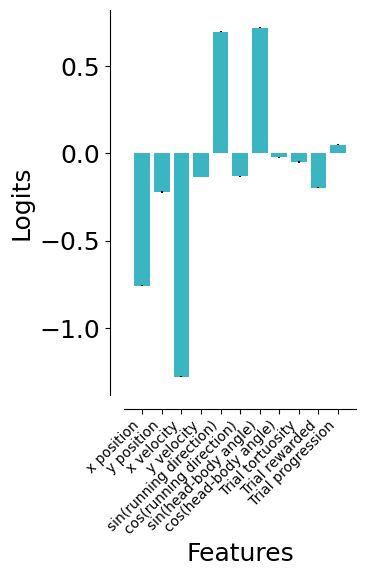

In [11]:
# Logits of the regression
fig, ax = plt.subplots(1, 1, figsize=(3, 5))
ax.bar(
    model_labels,
    np.mean(coef[:, 1:], axis=0),
    yerr=stats.sem(coef[:, 1:], axis=0),
    color="#3AB5C1"
)
sns.despine(offset=10, ax=ax)

ax.set_xticks(np.arange(len(model_labels))) 
ax.set_xticklabels(clean_model_labels, rotation=45, ha="right", fontsize=10)
ax.set_ylabel("Logits")
ax.set_xlabel("Features")

plt.savefig(save_fig_path + "dual_occluder_model_logits.svg", transparent=False)

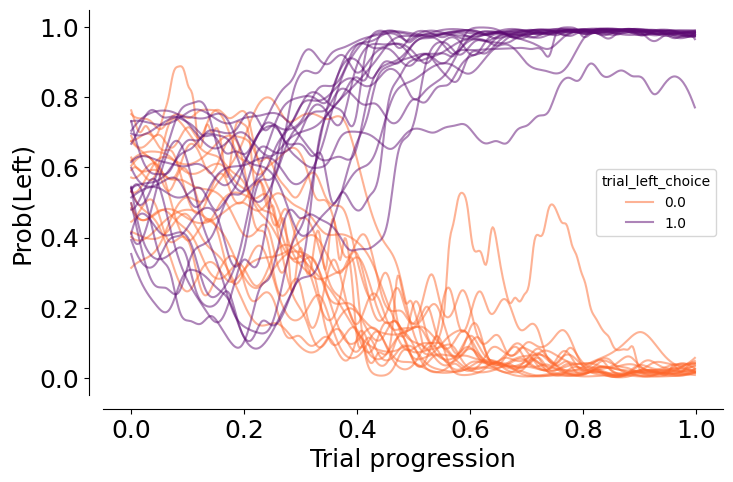

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

group = df_model[(df_model.dataset == df_model.dataset.unique()[15])]

trials = [94 , 15,  66, 170, 224, 195,  56, 203,  88, 239, 113,  91, 186, 248, 109, 164,
          188,  60, 229, 182, 156, 197,  52,  45, 110, 156, 190,  22, 210,  24,  51,  78, 
          239,  97,  24, 176, 168, 184, 123, 156]

group = group [group.trial.isin(np.array(trials))]
sns.lineplot(
        data=group,
        x="trial_length",
        y="proba_left",
        hue="trial_left_choice",
        errorbar=None,
        estimator=None,
        units="trial",
        palette= plotting.colors_choice[::-1],
        sort=False, alpha=0.5, ax=ax
    )
ax.set_ylabel("Prob(Left)")
ax.set_xlabel("Trial progression")
sns.despine(offset=10)
plt.savefig(save_fig_path + "dynamic_decision_variable.svg", transparent=True)

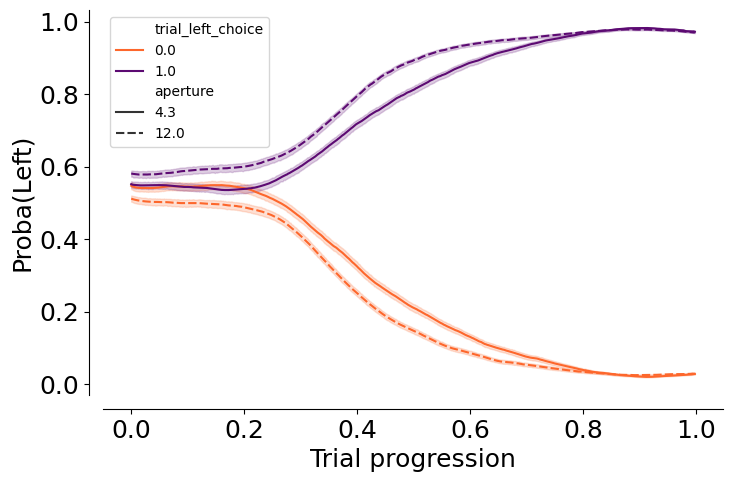

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
sns.lineplot(
        data=df_model,
        x="trial_length",
        y="proba_left",
        hue="trial_left_choice",
        style="aperture",
        palette= plotting.colors_choice[::-1],
        sort=False, alpha=1, ax=ax
    )
ax.set_ylabel("Proba(Left)")
ax.set_xlabel("Trial progression")
sns.despine(offset = 10)
plt.savefig(save_fig_path + "dynamic_decision_variable_mean.svg", transparent=True)

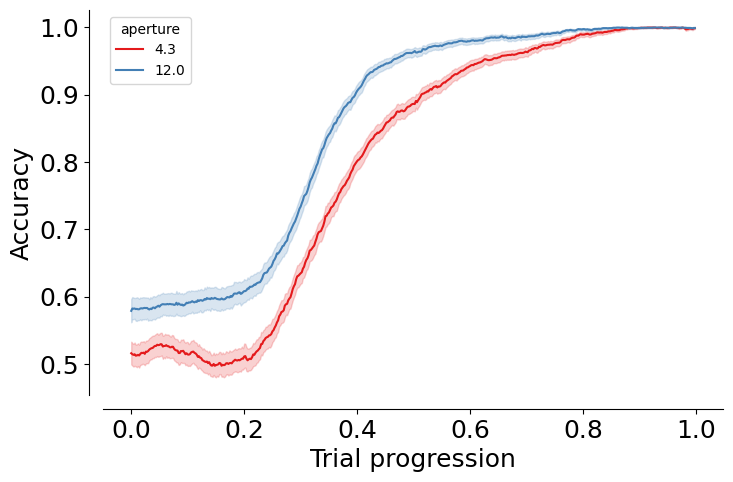

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
sns.lineplot(
        data=df_model,
        x="trial_length",
        y="accuracy",
        hue="aperture",
        palette= plotting.colors_aperture,
        sort=False, alpha=1, ax=ax
    )
ax.set_ylabel("Accuracy")
ax.set_xlabel("Trial progression")
sns.despine(offset=10)
plt.savefig(save_fig_path + "model_accuracy_variable.svg", transparent=True)

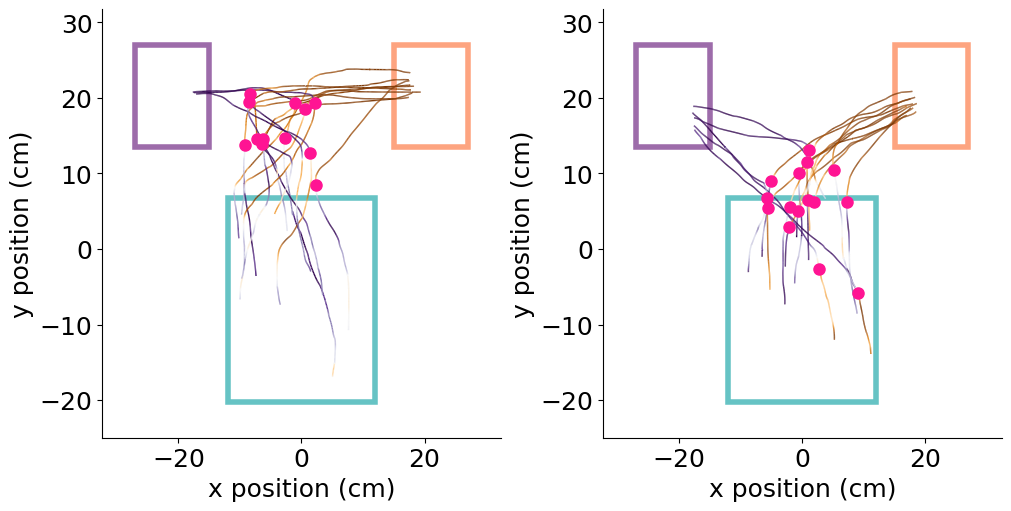

In [16]:
df_model["session"] = df_model["dataset"]
df_model["trial_L_choice"] = df_model["trial_left_choice"]
decision_points = regression.find_decision_point(df_model, threshold_uncertainty=0.3)
fig, ax = plt.subplots(1, len(df_model.aperture.unique()), figsize=(10, 5), constrained_layout=True)

decision_color = "deeppink"
session_to_plot = "Pheasant_2024-08-15_2"
box_df = base_analysis.BoxDataFrame().get_data(key={"dataset": "Pheasant_2024-08-15_2"})

trials = [44, 45,  19,  62, 61, 45,  85, 41, 43, 41, 50, 75, 24, 69, 84,
           74,  10] + [63, 30, 78, 47, 33, 5,  17, 9,
          47,  30, 99, 11, 12, 15]


for i, aperture in enumerate(df_model.aperture.unique()):
    regression.plot_decision_points_on_trajectory(
        df_model[
            (df_model.dataset == session_to_plot) & (df_model.aperture == aperture)
        ],
        box_df,
        decision_point=decision_points[(decision_points.dataset == session_to_plot) & (decision_points.aperture == aperture)],
        color=decision_color,
        trials=trials,
        ax=ax[i],
    )
    ax[i].set_xlabel("x position (cm)")
    ax[i].set_ylabel("y position (cm)")
plt.savefig(save_fig_path + "decision_points_trajectories.svg", transparent=True)

2025-02-12 10:19:11,534::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-12 10:19:11,534::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-12 10:19:11,539::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2025-02-12 10:19:11,539::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-12 10:19:11,610::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-12 10:19:11,610::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-12 10:19:11,621::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-12 10:19:11,621::INFO::category.py::Using categorical un

12.0-4.3: TtestResult(statistic=-9.935607323836335, pvalue=1.6306230343414416e-10, df=27)


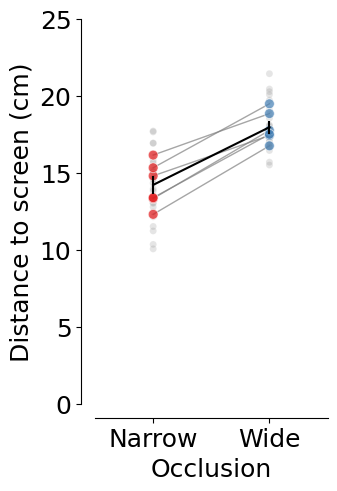

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(3, 5))
stats = plotting.pairplot_average_decision_point(decision_points, 
                                                 label_parameter="y",  
                                                 ax=ax, 
                                                 cmap=plotting.colors_aperture,
                                                 per_mouse=True)
ax.set_xlim(-.5,1.5)
ax.set_ylim(0,25)
ax.set_xlabel("Occlusion")
ax.set_xticks([0,1], ["Narrow", "Wide"])
ax.set_ylabel("Distance to screen (cm)")
sns.despine(offset=10)
plt.legend([],[], frameon=False)

plt.savefig(save_fig_path + "decision_points.svg", transparent = True)